# Introduction to Convolutional Neural Networks and Computer Vision with TensorFlow

Computer vision is the practice of writing algorithms which can discover patterns in visual data. Such as the camera of a self-driving car recognizing the car in front

## Get the data

The images we're working with are from the Food101 dataset (101 different classes of food): https://www.kaggle.com/dansbecker/food-101

However we've modified it to only use two classes (pizza 🍕 & steak 🥩) using the image data modification notebook: https://github.com/mrdbourke/tensorflow-deep-learning/blob/main/extras/image_data_modification.ipynb

> 🔑 **Note:** We start with a smaller dataset so we can experiment quickly and figure what works (or better yet what doesn't work) before scaling up.

In [4]:
import zipfile
import urllib.request

# Replace !wget with this
urllib.request.urlretrieve(
    "https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip",
    "pizza_steak.zip"
)

# Rest stays the same
zip_ref = zipfile.ZipFile("pizza_steak.zip")
zip_ref.extractall()
zip_ref.close()

## Inspect the data (become one with it)

A very crucial step at the beginning of any machine learning project is becoming one with the data.

And for a computer vision project... this usually means visualizing many samples of your data.

In [6]:
ls pizza_steak

 Volume in drive C is OS
 Volume Serial Number is 76C5-75FF

 Directory of c:\Users\Muhammad Mahdi\Documents\1. Project\Deep_Learning_With_Tensorflow\Learn_DL_With_Tensorflow\pizza_steak

01/10/2026  16:43    <DIR>          .
01/10/2026  16:43    <DIR>          ..
01/10/2026  16:43    <DIR>          test
01/10/2026  16:43    <DIR>          train
               0 File(s)              0 bytes
               4 Dir(s)  227.261.554.688 bytes free


In [12]:
!dir pizza_steak\train\

 Volume in drive C is OS
 Volume Serial Number is 76C5-75FF

 Directory of c:\Users\Muhammad Mahdi\Documents\1. Project\Deep_Learning_With_Tensorflow\Learn_DL_With_Tensorflow\pizza_steak\train

01/10/2026  16:43    <DIR>          .
01/10/2026  16:43    <DIR>          ..
01/10/2026  16:43    <DIR>          pizza
01/10/2026  16:43    <DIR>          steak
               0 File(s)              0 bytes
               4 Dir(s)  227.450.327.040 bytes free


In [14]:
!dir pizza_steak\train\steak

 Volume in drive C is OS
 Volume Serial Number is 76C5-75FF

 Directory of c:\Users\Muhammad Mahdi\Documents\1. Project\Deep_Learning_With_Tensorflow\Learn_DL_With_Tensorflow\pizza_steak\train\steak

01/10/2026  16:43    <DIR>          .
01/10/2026  16:43    <DIR>          ..
01/10/2026  16:43            36.185 1000205.jpg
01/10/2026  16:43            34.497 100135.jpg
01/10/2026  16:43           116.802 101312.jpg
01/10/2026  16:43            56.754 1021458.jpg
01/10/2026  16:43            34.143 1032846.jpg
01/10/2026  16:43            24.688 10380.jpg
01/10/2026  16:43            37.134 1049459.jpg
01/10/2026  16:43            49.841 1053665.jpg
01/10/2026  16:43            59.983 1068516.jpg
01/10/2026  16:43            28.996 1068975.jpg
01/10/2026  16:43            29.525 1081258.jpg
01/10/2026  16:43            49.577 1090122.jpg
01/10/2026  16:43            59.976 1093966.jpg
01/10/2026  16:43            60.253 1098844.jpg
01/10/2026  16:43            69.843 1100074.jpg
01/10/2

In [13]:
import os

# Walk through pizza_steak directory and list number of files
for dirpath, dirnames, filenames in os.walk("pizza_steak"):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

There are 2 directories and 0 images in 'pizza_steak'.
There are 2 directories and 0 images in 'pizza_steak\test'.
There are 0 directories and 250 images in 'pizza_steak\test\pizza'.
There are 0 directories and 250 images in 'pizza_steak\test\steak'.
There are 2 directories and 0 images in 'pizza_steak\train'.
There are 0 directories and 750 images in 'pizza_steak\train\pizza'.
There are 0 directories and 750 images in 'pizza_steak\train\steak'.


In [16]:
# Another way to find ut how many images are in a file
num_steak_images_train = len(os.listdir("pizza_steak/train/steak"))

num_steak_images_train

750

To visualize our images, first let's get the class names programmatically.

In [17]:
# Get the classnames programmatically
import pathlib
import numpy as np
data_dir = pathlib.Path("pizza_steak/train")
class_names = np.array(sorted([item.name for item in data_dir.glob("*")])) # Created a list of class_names from the subdirectories
print(class_names)

['pizza' 'steak']


In [ ]:
# Let's visualize our images
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

def view_random_image(target_dir, target_class):
    # Setup the target directory (we'll view images from here)
    target_folder = target_dir+target_class

    # Get a random image path
    random_image = random.sample(os.listdir(target_folder), 1)
    print(random_image)

    # Read in the image and plot it using matplotlib
    img = mpimg.imread(target_folder + "/" + random_image[0])
    # you need [0] because random.sample returns a list that you can't join with a string
    plt.imshow(img)
    plt.title(target_class)
    plt.axis('off');

    print(f"Image shape: {img.shape}") # show the shape of the image

    return img

['1137400.jpg']
Image shape: (512, 512, 3)


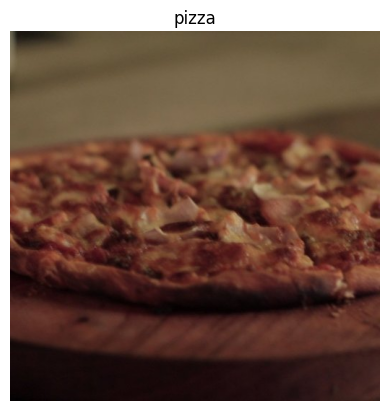

In [51]:
# View a random image from the training dataset
img = view_random_image(
    target_dir="pizza_steak/train/",
    target_class="pizza"
)

In [52]:
224, 224, 3

(224, 224, 3)

In [25]:
random_image = random.choice(os.listdir("pizza_steak/train/steak/"))

random_image


'3011642.jpg'

In [53]:
# The images we've imported and plotted are actually giant arrays/tensors of different pixel values
import tensorflow as tf
tf.constant(img)

<tf.Tensor: shape=(512, 512, 3), dtype=uint8, numpy=
array([[[105, 103,  82],
        [ 98,  96,  75],
        [ 94,  91,  74],
        ...,
        [109,  94,  63],
        [109,  94,  63],
        [108,  93,  62]],

       [[106, 104,  83],
        [ 99,  97,  76],
        [ 95,  92,  73],
        ...,
        [109,  94,  63],
        [109,  94,  63],
        [109,  94,  63]],

       [[109, 104,  84],
        [103,  98,  78],
        [ 96,  93,  74],
        ...,
        [109,  94,  63],
        [109,  94,  63],
        [109,  94,  63]],

       ...,

       [[  4,   2,   3],
        [  4,   2,   3],
        [  4,   2,   3],
        ...,
        [ 55,  31,  27],
        [ 55,  31,  27],
        [ 53,  32,  27]],

       [[  5,   3,   4],
        [  5,   3,   4],
        [  4,   2,   3],
        ...,
        [ 53,  32,  27],
        [ 52,  31,  26],
        [ 51,  32,  26]],

       [[  5,   3,   4],
        [  5,   3,   4],
        [  5,   3,   4],
        ...,
        [ 53,  32,  2

In [54]:
# View the image shape
img.shape # returns width, height, colour channels

(512, 512, 3)

> 🔑 **Note:** As we've discussed before, many machine learning models, including neural networks prefer the values they work with to be between 0 and 1. Knowing this, one of the most common preprocessing steps for working with images is to **scale** (also referred to as **normalize**) their pixel values by dividing the image arrays by 255. (since 255 is the maximum pixel value).

In [55]:
# Get all the pixel values between 0 & 1
img/255.

array([[[0.41176471, 0.40392157, 0.32156863],
        [0.38431373, 0.37647059, 0.29411765],
        [0.36862745, 0.35686275, 0.29019608],
        ...,
        [0.42745098, 0.36862745, 0.24705882],
        [0.42745098, 0.36862745, 0.24705882],
        [0.42352941, 0.36470588, 0.24313725]],

       [[0.41568627, 0.40784314, 0.3254902 ],
        [0.38823529, 0.38039216, 0.29803922],
        [0.37254902, 0.36078431, 0.28627451],
        ...,
        [0.42745098, 0.36862745, 0.24705882],
        [0.42745098, 0.36862745, 0.24705882],
        [0.42745098, 0.36862745, 0.24705882]],

       [[0.42745098, 0.40784314, 0.32941176],
        [0.40392157, 0.38431373, 0.30588235],
        [0.37647059, 0.36470588, 0.29019608],
        ...,
        [0.42745098, 0.36862745, 0.24705882],
        [0.42745098, 0.36862745, 0.24705882],
        [0.42745098, 0.36862745, 0.24705882]],

       ...,

       [[0.01568627, 0.00784314, 0.01176471],
        [0.01568627, 0.00784314, 0.01176471],
        [0.01568627, 0

## An end-to-end example 

Let's build a convolutional neural network to find patterns in our images, more specifically we a need way to:

* Load our images
* Preprocess our images
* Build a CNN to find patterns in our images
* Compile our CNN
* Fit the CNN to our training data

In [61]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Set the seed
tf.random.set_seed(42)

# Preprocess data (get all of the pixel values between 0 & 1, also called scaling/normalization)
train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)

# Set up paths to our data directories
train_dir = "pizza_steak/train/"
test_dir = "pizza_steak/test/"

# Import data from directories and turn it into batches
train_data = train_datagen.flow_from_directory(
    directory=train_dir,
    batch_size=32,
    target_size=(224, 224),
    class_mode='binary',
    seed=42
)

valid_data = valid_datagen.flow_from_directory(
    directory=test_dir,
    batch_size=32,
    target_size=(224, 224),
    class_mode='binary',
    seed=42
)

# Build a CNN model (same as the Tiny VGG on the CNN explainer website)
model_1 = tf.keras.Sequential([
    tf.keras.layers.Conv2D(
        filters=10,
        kernel_size=3,
        activation='relu',
        input_shape=(224, 224, 3)
    ),
    tf.keras.layers.Conv2D(10, 3, activation='relu'),
    tf.keras.layers.MaxPool2D(pool_size=2, padding='valid'),
    tf.keras.layers.Conv2D(10, 3, activation='relu'),
    tf.keras.layers.Conv2D(10, 3, activation='relu'),
    tf.keras.layers.MaxPool2D(pool_size=2, padding='valid'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile our CNN
model_1.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(),
    metrics=['accuracy']
)

# Fit the model
history_1 = model_1.fit(
    train_data, epochs=5, steps_per_epoch=len(train_data),
    validation_data=valid_data, validation_steps=len(valid_data))

Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.
Epoch 1/5
47/47 [==============================] - 29s 398ms/step - loss: 0.5784 - accuracy: 0.7027 - val_loss: 0.4645 - val_accuracy: 0.7840
Epoch 2/5
47/47 [==============================] - 6s 118ms/step - loss: 0.4489 - accuracy: 0.8007 - val_loss: 0.3898 - val_accuracy: 0.8340
Epoch 3/5
47/47 [==============================] - 5s 96ms/step - loss: 0.4251 - accuracy: 0.8033 - val_loss: 0.3780 - val_accuracy: 0.8360
Epoch 4/5
47/47 [==============================] - 4s 95ms/step - loss: 0.3706 - accuracy: 0.8460 - val_loss: 0.3226 - val_accuracy: 0.8720
Epoch 5/5
47/47 [==============================] - 5s 100ms/step - loss: 0.3204 - accuracy: 0.8713 - val_loss: 0.3210 - val_accuracy: 0.8420


In [60]:
train_data.image_shape

(224, 224, 3)